In [2]:
#algorithm to found connected surfaces 
#purpose to find clouds in 3d space and time based on locating threshold
#https://en.wikipedia.org/wiki/Breadth-first_search

In [1]:
print('Importing libraries')
import numpy as np
import matplotlib.pyplot as plt
import xarray as xr
import os; import time

#Following BFS algorithms only work on binary (0,1) arrays

Importing libraries


In [ ]:
# print('Loading functions')
# def shape_search_4d(array): #4-D Shape Searching Algorithm (based on breadth-first search) 
#     final_array=np.zeros_like(array); total_1s = len(np.where(array==1)[0]) 
#     #Functions 
#     def next_most_1_4d(array): #finds next most 1
#         if len(np.where(array==1)[0])!=0:
#             result=tuple(arr[0] for arr in np.where(array==1))
#             return result
#         else:
#             return (-1,-1,-1,-1)
#     ######################################################################   
#     def find_neighbor_index_4d(array,container): #find the indexes of all neighbors
                    
#         #neighbors that are 0 or exist in visit or queue are not appended to neighbors
#         tup,neighbors=[],[]
        
#         container=[tuple(sub) for sub in container]; 
#         nx,ny,nz,nt=array.shape[3]-1,array.shape[2]-1,array.shape[1]-1,array.shape[0]-1
        
#         for index in container:
#             if index==(-1,-1,-1,-1):
#                 pass
#             else:
#                 ######################################################################  
#                 #code for inside #all possible neighbors
#                 tup=[[index[0]-1,index[1]-1,index[2]-1,index[3]-1],[index[0]-1,index[1]-1,index[2]-1,index[3]],[index[0]-1,index[1]-1,index[2]-1,index[3]+1], #previous time
#                      [index[0]-1,index[1]-1,index[2],index[3]-1],[index[0]-1,index[1]-1,index[2],index[3]],[index[0]-1,index[1]-1,index[2],index[3]+1],
#                      [index[0]-1,index[1]-1,index[2]+1,index[3]-1],[index[0]-1,index[1]-1,index[2]+1,index[3]],[index[0]-1,index[1]-1,index[2]+1,index[3]+1],

#                      [index[0]-1,index[1],index[2]-1,index[3]-1],[index[0]-1,index[1],index[2]-1,index[3]],[index[0]-1,index[1],index[2]-1,index[3]+1],
#                      [index[0]-1,index[1],index[2],index[3]-1],[index[0]-1,index[1],index[2],index[3]],[index[0]-1,index[1],index[2],index[3]+1],
#                      [index[0]-1,index[1],index[2]+1,index[3]-1],[index[0]-1,index[1],index[2]+1,index[3]],[index[0]-1,index[1],index[2]+1,index[3]+1],

#                      [index[0]-1,index[1]+1,index[2]-1,index[3]-1],[index[0]-1,index[1]+1,index[2]-1,index[3]],[index[0]-1,index[1]+1,index[2]-1,index[3]+1],
#                      [index[0]-1,index[1]+1,index[2],index[3]-1],[index[0]-1,index[1]+1,index[2],index[3]],[index[0]-1,index[1]+1,index[2],index[3]+1],
#                      [index[0]-1,index[1]+1,index[2]+1,index[3]-1],[index[0]-1,index[1]+1,index[2]+1,index[3]],[index[0]-1,index[1]+1,index[2]+1,index[3]+1],  


#                      [index[0],index[1]-1,index[2]-1,index[3]-1],[index[0],index[1]-1,index[2]-1,index[3]],[index[0],index[1]-1,index[2]-1,index[3]+1], #current time
#                      [index[0],index[1]-1,index[2],index[3]-1],[index[0],index[1]-1,index[2],index[3]],[index[0],index[1]-1,index[2],index[3]+1],
#                      [index[0],index[1]-1,index[2]+1,index[3]-1],[index[0],index[1]-1,index[2]+1,index[3]],[index[0],index[1]-1,index[2]+1,index[3]+1],

#                      [index[0],index[1],index[2]-1,index[3]-1],[index[0],index[1],index[2]-1,index[3]],[index[0],index[1],index[2]-1,index[3]+1],
#                      [index[0],index[1],index[2],index[3]-1],[index[0],index[1],index[2],index[3]],[index[0],index[1],index[2],index[3]+1],
#                      [index[0],index[1],index[2]+1,index[3]-1],[index[0],index[1],index[2]+1,index[3]],[index[0],index[1],index[2]+1,index[3]+1],

#                      [index[0],index[1]+1,index[2]-1,index[3]-1],[index[0],index[1]+1,index[2]-1,index[3]],[index[0],index[1]+1,index[2]-1,index[3]+1],
#                      [index[0],index[1]+1,index[2],index[3]-1],[index[0],index[1]+1,index[2],index[3]],[index[0],index[1]+1,index[2],index[3]+1],
#                      [index[0],index[1]+1,index[2]+1,index[3]-1],[index[0],index[1]+1,index[2]+1,index[3]],[index[0],index[1]+1,index[2]+1,index[3]+1],


#                      [index[0]+1,index[1]-1,index[2]-1,index[3]-1],[index[0]+1,index[1]-1,index[2]-1,index[3]],[index[0]+1,index[1]-1,index[2]-1,index[3]+1], #future time
#                      [index[0]+1,index[1]-1,index[2],index[3]-1],[index[0]+1,index[1]-1,index[2],index[3]],[index[0]+1,index[1]-1,index[2],index[3]+1],
#                      [index[0]+1,index[1]-1,index[2]+1,index[3]-1],[index[0]+1,index[1]-1,index[2]+1,index[3]],[index[0]+1,index[1]-1,index[2]+1,index[3]+1],

#                      [index[0]+1,index[1],index[2]-1,index[3]-1],[index[0]+1,index[1],index[2]-1,index[3]],[index[0]+1,index[1],index[2]-1,index[3]+1],
#                      [index[0]+1,index[1],index[2],index[3]-1],[index[0]+1,index[1],index[2],index[3]],[index[0]+1,index[1],index[2],index[3]+1],
#                      [index[0]+1,index[1],index[2]+1,index[3]-1],[index[0]+1,index[1],index[2]+1,index[3]],[index[0]+1,index[1],index[2]+1,index[3]+1],

#                      [index[0]+1,index[1]+1,index[2]-1,index[3]-1],[index[0]+1,index[1]+1,index[2]-1,index[3]],[index[0]+1,index[1]+1,index[2]-1,index[3]+1],
#                      [index[0]+1,index[1]+1,index[2],index[3]-1],[index[0]+1,index[1]+1,index[2],index[3]],[index[0]+1,index[1]+1,index[2],index[3]+1],
#                      [index[0]+1,index[1]+1,index[2]+1,index[3]-1],[index[0]+1,index[1]+1,index[2]+1,index[3]],[index[0]+1,index[1]+1,index[2]+1,index[3]+1],
#                     ]  

#                 #code for edges and corners 
#                 tup=[sublist for sublist in tup if 0 <= sublist[0] <= nt] 
#                 tup=[sublist for sublist in tup if 0 <= sublist[1] <= nz] 
#                 tup=[[sublist[0],sublist[1],np.mod(sublist[2],ny+1),sublist[3]] for sublist in tup] #use if y boundaries are periodic
#                 # tup=[[sublist[0],sublist[1],sublist[2],np.mod(sublist[3],nx+1)] for sublist in tup] #use if x boundaries are periodic
#                 tup=[sublist for sublist in tup if 0 <= sublist[3] <= nx] #use if x not periodic
#                 if tup: [neighbors.append(sub) for sub in tup]
#                 ######################################################################  
#             if neighbors: #only if neighbors exists
#                 neighbors=np.unique(neighbors,axis=0).tolist()
#                 neighbors=[tuple(sub) for sub in neighbors if array[tuple(sub)] != 0 and tuple(sub) not in container] 
        
#         if not neighbors:
#             neighbors=np.full((0,4),0,dtype=int)    
#         else: neighbors=np.array(neighbors)
#         return neighbors
#     ###################################################################### 
    
#     #The Algorithm
#     n,k=0,0 #n is current shape, k is number of iterations on current shape 
    
#     while True:
#         n+=1;
#         if np.mod(n,1)==0:
#              found_1s=len(np.where(array==1)[0]); print("Current shape number: " + str(n) + " (" + str(round(100*(1-found_1s/total_1s),2)) + "%)")
#         visit=np.full((0,4),0,dtype=int) #creates visit variable for current shapes
#         queue=np.full((0,4),0,dtype=int) #creates queue variable for possible neighbors

#         ######################################################################
#         #finds the first 1 in the array, append to visit, and zero out
#         index=next_most_1_4d(array); 
#         visit=np.concatenate([visit,[index]]);array[index]=0; 

#         #finds neighbors of first index and appends to queue
#         neighbors=find_neighbor_index_4d(array,visit)
#         queue=np.concatenate([queue,neighbors]) 

#         #for rest of individual shape
#         while queue.size!=0: 
#             k+=1
#             #add all queued indexes to visit and find unique,nonzero,and nonvisited neighbor
#             visit=np.concatenate([visit,queue]);neighbors=find_neighbor_index_4d(array,queue)
#             #zero out queued in array and empty out queue
#             array[queue[:,0],queue[:,1],queue[:,2],queue[:,3]]=0; queue=np.full((0,4),0,dtype=int) 
#             #append found neighbor to queue
#             queue=np.concatenate([queue,neighbors]) 
                
#             #failsafes to end while loop
#             if queue.size==0: 
#                 break #breaks single loop for current shape if no more neighbor
#             if k>=array.shape[0]*array.shape[1]*array.shape[2]*array.shape[3]: #k failsafe, set to max volume of array
#                 break  
#         #sets output array's value to shape number       
#         if index!=(-1,-1,-1,-1):
#             final_array[visit[:,0],visit[:,1],visit[:,2],visit[:,3]] = n #sets final array location to shape number
#         ######################################################################  
    
#         #failsafes to end while loop
#         if index==(-1,-1,-1,-1):
#             print("no more shapes are left")
#             print(f"total of {n-1} shapes were found")
#             break  #break loop if no more 1s
#         if n>=array.shape[0]*array.shape[1]*array.shape[2]*array.shape[3]:  #n failsafe, set to max volume of array
#             print("failsafe reached")
#             break  #break loop if no more 1s
#     #Save final array to external nc file
#     xr.DataArray(final_array, dims=('t','z','y', 'x'),name='var').to_netcdf('cloud_shapes_4d.nc')
#     return final_array
# ##########################################################################################################################################  

# #Import Data 
# # ###################################################################### 
# print('Reading data')
# data= xr.open_dataset('/mnt/lustre/koa/koastore/torri_group/air/cm1r20.3/run/cm1out_test3.nc') #(241,34,64,256) #2.68% in 38 minutes 
# print(f'Dimension of data: {dict(data.sizes)}')
# data=data.isel(time=slice(200,225)) #take a time slice


# # var_list= [x for x in data]    
# # for i, var_name in enumerate(var_list, start=1):
# #     print(f"({i-1}) {var_name}")

# #Load qc, qi, buoyancy, and w
# zlev= 15
# t= 180 #xy slice at zh=10 and time=120/241
# qc=data['qc'].values
# qi=data['qi'].values
# buoyancy=data['buoyancy'].values
# w=data['w'].values

# #Threshold Data
# cloud_thresh= np.where(qc > 10e-5) or np.where(qi > 10e-5)
# updraft_thresh=np.where( ( (qc > 10e-5) | (qi > 10e-5) ) & (buoyancy>0))
# # core_thresh=np.where( ( (qc > 10e-5) | (qi > 10e-5) ) & (w>0.5))
# #add 1s where threshhold is passed
# data=np.zeros_like(qc); data[cloud_thresh]=1;
# array=data.copy() #creates temporary array variable 
# # ###################################################################### 

# #Running the Algorithm
# ######################################################################  
# start_time = time.time();
# print('Started algorithm')
# final_array=shape_search_4d(array)
# end_time = time.time(); elapsed_time = end_time - start_time
# print(f"Total Elapsed Time: {elapsed_time} seconds")
# ######################################################################  


# #Plotting for Testing
# ######################################################################  
# plt.subplot(2, 1, 1)
# plot_array=data.copy(); 
# plt.imshow(plot_array[2,14,:,:],cmap='viridis')
# plt.subplot(2, 1, 2)
# plt.imshow(final_array[2,14,:,:],cmap='gist_ncar')
# ######################################################################  

Dimension of data: {'one': 1, 'time': 1441, 'xh': 512, 'xf': 513, 'yh': 64, 'yf': 65, 'zh': 34, 'zf': 35}
Current shape number: 15 (22.25%)
Current shape number: 30 (22.86%)
Current shape number: 45 (27.64%)
Current shape number: 60 (34.66%)
Current shape number: 75 (40.12%)
Current shape number: 90 (42.76%)
Current shape number: 105 (48.17%)
Current shape number: 120 (51.55%)
Current shape number: 135 (56.08%)
Current shape number: 150 (57.5%)
Current shape number: 165 (60.54%)
Current shape number: 180 (63.14%)
Current shape number: 195 (65.61%)
Current shape number: 210 (69.26%)
Current shape number: 225 (74.04%)
Current shape number: 240 (79.17%)
Current shape number: 255 (82.94%)
Current shape number: 270 (85.92%)
Current shape number: 285 (89.63%)
Current shape number: 300 (90.65%)
Current shape number: 315 (92.45%)
Current shape number: 330 (94.72%)
Current shape number: 345 (95.42%)
Current shape number: 360 (98.46%)
Current shape number: 375 (99.87%)
no more shapes are left
to

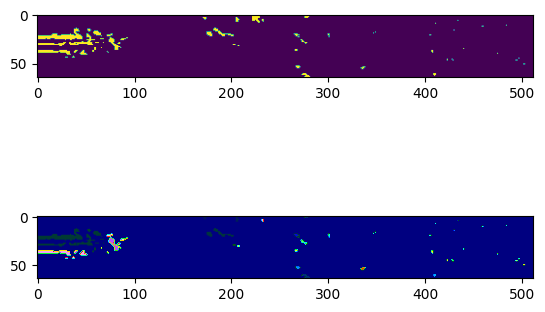

In [15]:
def shape_search_3d(array): #3-D Shape Searching Algorithm (based on breadth-first search) 
    final_array=np.zeros_like(array); total_1s = len(np.where(array==1)[0]) 
    #Functions 
    def next_most_1_3d(array): #finds next most 1
        if len(np.where(array==1)[0])!=0:
            result=tuple(arr[0] for arr in np.where(array==1))
            return result
        else:
            return (-1,-1,-1)
    ######################################################################   
    def find_neighbor_index_3d(array,container): #find the indexes of all neighbors
                    
        #neighbors that are 0 or exist in visit or queue are not appended to neighbors
        tup,neighbors=[],[]
        
        container=[tuple(sub) for sub in container]; 
        nx,ny,nz=array.shape[2]-1,array.shape[1]-1,array.shape[0]-1
        
        for index in container:
            if index==(-1,-1,-1):
                pass
            else:
                ######################################################################  
                #code for inside #all possible neighbors
                tup=[[index[0]-1,index[1]-1,index[2]-1],[index[0]-1,index[1]-1,index[2]],[index[0]-1,index[1]-1,index[2]+1], 
                     [index[0]-1,index[1],index[2]-1],[index[0]-1,index[1],index[2]],[index[0]-1,index[1],index[2]+1],
                     [index[0]-1,index[1]+1,index[2]-1],[index[0]-1,index[1]+1,index[2]],[index[0]-1,index[1]+1,index[2]+1],

                     [index[0],index[1]-1,index[2]-1],[index[0],index[1]-1,index[2]],[index[0],index[1]-1,index[2]+1],
                     [index[0],index[1],index[2]-1],[index[0],index[1],index[2]],[index[0],index[1],index[2]+1],
                     [index[0],index[1]+1,index[2]-1],[index[0],index[1]+1,index[2]],[index[0],index[1]+1,index[2]+1],

                     [index[0]+1,index[1]-1,index[2]-1],[index[0]+1,index[1]-1,index[2]],[index[0]+1,index[1]-1,index[2]+1],
                     [index[0]+1,index[1],index[2]-1],[index[0]+1,index[1],index[2]],[index[0]+1,index[1],index[2]+1],
                     [index[0]+1,index[1]+1,index[2]-1],[index[0]+1,index[1]+1,index[2]],[index[0]+1,index[1]+1,index[2]+1],  
                    ]  
                #code for edges and corners 
                tup=[sublist for sublist in tup if 0 <= sublist[0] <= nz] 
                tup=[[sublist[0],np.mod(sublist[1],ny+1),sublist[2]] for sublist in tup] #use if y boundaries are periodic
                # tup=[sublist[0],sublist[1],[np.mod(sublist[2],nx+1)] for sublist in tup] #use if x boundaries are periodic
                tup=[sublist for sublist in tup if 0 <= sublist[2] <= nx] #use if x not periodic
                if tup: [neighbors.append(sub) for sub in tup]
                ######################################################################   
            if neighbors: #only if neighbors exists
                neighbors=np.unique(neighbors,axis=0).tolist()
                neighbors=[tuple(sub) for sub in neighbors if array[tuple(sub)] != 0 and tuple(sub) not in container] 
        
        if not neighbors:
            neighbors=np.full((0,3),0,dtype=int)    
        else: neighbors=np.array(neighbors)
        return neighbors
    ###################################################################### 
    
    #The Algorithm
    n,k=0,0 #n is current shape, k is number of iterations on current shape 
    
    while True:
        n+=1;
        if np.mod(n,15)==0:
             found_1s=len(np.where(array==1)[0]); print("Current shape number: " + str(n) + " (" + str(round(100*(1-found_1s/total_1s),2)) + "%)")
        visit=np.full((0,3),0,dtype=int) #creates visit variable for current shapes
        queue=np.full((0,3),0,dtype=int) #creates queue variable for possible neighbors

        ######################################################################
        #finds the first 1 in the array, append to visit, and zero out
        index=next_most_1_3d(array); 
        visit=np.concatenate([visit,[index]]);array[index]=0;

        #finds neighbors of first index and appends to queue
        neighbors=find_neighbor_index_3d(array,visit) 
        queue=np.concatenate([queue,neighbors])
        
        #for rest of individual shape
        while queue.size!=0: 
            k+=1
            #add all queued indexes to visit and find unique,nonzero,and nonvisited neighbor
            visit=np.concatenate([visit,queue]);neighbors=find_neighbor_index_3d(array,queue) 
            #zero out queued in array and empty out queue
            array[queue[:,0],queue[:,1],queue[:,2]]=0; queue=np.full((0,3),0,dtype=int) 
            #append found neighbor to queue
            queue=np.concatenate([queue,neighbors]) #append additional neighbors to queue
            
            #failsafes to end while loop    
            if queue.size==0: 
                break #breaks single loop for current shape if no more neighbor
            if k>=array.shape[0]*array.shape[1]*array.shape[2]: #k failsafe, set to max volume of array
                break   
        #sets output array's value to shape number
        if index!=(-1,-1,-1):
            final_array[visit[:,0],visit[:,1],visit[:,2]] = n #sets final array location to shape number
        ######################################################################  
        
        #failsafes to end while loop    
        if index==(-1,-1,-1):
            print("no more shapes are left")
            print(f"total of {n-1} shapes were found")
            break  #break loop if no more 1s
        if n>=array.shape[0]*array.shape[1]*array.shape[2]:  #n failsafe, set to max volume of array
            print("failsafe reached")
            break  #break loop if no more 1s
    #Save final array to external nc file
    xr.DataArray(final_array, dims=('z','y', 'x'),name='var').to_netcdf('cloud_shapes_3d.nc')
    return final_array
##########################################################################################################################################  

#Import Data
######################################################################  
layer=np.array([[1,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1],
                [0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0],
                [0,0,1,1,1,0,0,0,0,1,1,1,0,0,0,0,1,1,1,0,0],
                [0,0,1,1,1,0,0,0,0,1,1,1,0,0,0,0,1,1,1,0,0],
                [0,0,1,1,1,0,0,0,0,1,1,1,0,0,0,0,1,1,1,0,0],
                [1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1],
                [0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1],
                [0,0,1,0,1,0,0,0,0,0,1,1,0,0,0,0,1,1,1,0,0],
                [0,0,0,1,0,0,0,0,0,1,1,0,1,1,1,0,1,1,1,0,0],
                [0,0,1,0,1,0,0,0,0,1,0,0,0,0,0,0,1,1,0,0,0],
                [0,0,0,0,0,0,0,0,0,0,0,0,1,0,1,0,0,0,0,0,0],
                [1,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1]])
layer = np.repeat(layer, 5, axis=0)
layer = np.repeat(layer, 25, axis=1)
data = np.repeat(layer[np.newaxis, :, :], 34, axis=0) #data shape (34, 60, 525) #32 minutes
array=data.copy() #creates temporary array variable 
# ###################################################################### 
data=xr.open_dataset(dir+'cm1r20.3/run/cm1out_test7tundra-7_062217.nc') #***
print(f'Dimension of data: {dict(data.sizes)}')
var_list= [x for x in data]
# for i, var_name in enumerate(var_list, start=1):
#     print(f"({i-1}) {var_name}")

#Load qc, qi, buoyancy, and w
t= 750 #xy slice at zh=10 and time=120/241
qc=data['qc'].isel(time=t).values
qi=data['qi'].isel(time=t).values
buoyancy=data['buoyancy'].isel(time=t).values
w=data['w'].isel(time=t).values

#Threshold Data
cloud_thresh= np.where(qc > 10e-5) or np.where(qi > 10e-5)
updraft_thresh=np.where( ( (qc > 10e-5) | (qi > 10e-5) ) & (buoyancy>0))
# core_thresh=np.where( ( (qc > 10e-5) | (qi > 10e-5) ) & (w>0.5))
#add 1s where threshhold is passed
data=np.zeros_like(qc); data[cloud_thresh]=1;
array=data.copy() #creates temporary array variable 
# ###################################################################### 

#Running the Algorithm
######################################################################  
start_time = time.time();
final_array=shape_search_3d(array)
end_time = time.time(); elapsed_time = end_time - start_time
print(f"Total Elapsed Time: {elapsed_time} seconds")
######################################################################  

#Plotting for Testing
######################################################################  
plt.subplot(2, 1, 1)
plot_array=data.copy();
plt.imshow(plot_array[14,:,:],cmap='viridis')
plt.subplot(2, 1, 2)
plt.imshow(final_array[14,:,:],cmap='gist_ncar')
######################################################################  

Current shape number: 5
Current shape number: 10
no more shapes are left
total of 13 shapes were found
Total Elapsed Time: 0.06005239486694336 seconds


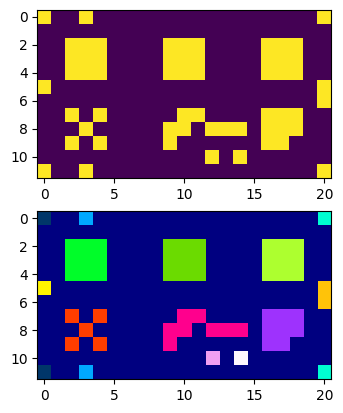

In [4]:
def shape_search_2d(array): #2-D Shape Searching Algorithm (based on breadth-first search) 
    final_array=np.zeros_like(array)
    #Functions 
    def next_most_1_2d(array): #finds next most 1
        if len(np.where(array==1)[0])!=0:
            result=tuple(arr[0] for arr in np.where(array==1))
            return result
        else:
            return (-1,-1)
    ######################################################################   
    def find_neighbor_index_2d(array,container): #find the indexes of all neighbors
                    
        #neighbors that are 0 or exist in visit or queue are not appended to neighbors
        tup,neighbors=[],[]
        container=[tuple(sub) for sub in container]; 
        nx,ny=array.shape[1]-1,array.shape[0]-1
        
        for index in container:
            if index==(-1,-1):
                pass
            else: 
                ######################################################################   
                #code for inside #all possible neighbors
                tup=[[index[0]-1,index[1]-1],[index[0]-1,index[1]],[index[0]-1,index[1]+1], 
                    [index[0],index[1]-1],[index[0],index[1]+1],
                    [index[0]+1,index[1]-1],[index[0]+1,index[1]],[index[0]+1,index[1]+1]] 
                #code for edges and corners 
                tup=[[np.mod(sublist[0],ny+1),sublist[1]] for sublist in tup] #use if y boundaries are periodic
                # tup=[sublist[0],sublist[1],[np.mod(sublist[1],nx+1)] for sublist in tup] #use if x boundaries are periodic
                tup=[sublist for sublist in tup if 0 <= sublist[1] <= nx] #use if x not periodic 
                if tup: [neighbors.append(sub) for sub in tup]
                ######################################################################             
            if neighbors:  #only unique elements that are not visited
                neighbors=np.unique(neighbors,axis=0).tolist()
                neighbors=[tuple(sub) for sub in neighbors if array[tuple(sub)] != 0 and tuple(sub) not in container]

        if not neighbors:
            neighbors=np.full((0,2),0,dtype=int)    
        else: neighbors=np.array(neighbors)
        return neighbors
    ###################################################################### 
    
    #The Algorithm
    n,k=0,0 #n is current shape, k is number of iterations on current shape 
    while True:
        n+=1;
        if np.mod(n,5)==0:
            print("Current shape number: " + str(n))
        visit=np.full((0,2),0,dtype=int) #creates visit variable for current shapes
        queue=np.full((0,2),0,dtype=int) #creates queue variable for possible neighbors

        ######################################################################
        #finds the first 1 in the array, append to visit, and zero out
        index=next_most_1_2d(array);
        visit=np.concatenate([visit,[index]]);array[index]=0;
        
        #finds neighbors of first index and appends to queue
        neighbors=find_neighbor_index_2d(array,visit) 
        queue=np.concatenate([queue,neighbors]) 

        #for rest of individual shape
        while queue.size!=0: 
            k+=1
            #add all queued indexes to visit and find unique,nonzero,and nonvisited neighbor
            visit=np.concatenate([visit,queue]); neighbors=find_neighbor_index_2d(array,queue) 
            #zero out queued in array and empty out queue
            array[queue[:, 0], queue[:, 1]] = 0; queue=np.full((0,2),0,dtype=int) 
            #append found neighbor to queue
            queue=np.concatenate([queue,neighbors])
                
            #failsafes to end while loop
            if queue.size==0: 
                break #breaks single loop for current shape if no more neighbor
            if k>=array.shape[0]*array.shape[1]: #k failsafe, set to max volume of array
                break    
        #sets output array's value to shape number
        if index!=(-1,-1):
            final_array[visit[:, 0], visit[:, 1]] = n #sets final array location to shape number
        ######################################################################  
        
        #failsafes to end while loop
        if index==(-1,-1):
            print("no more shapes are left")
            print(f"total of {n-1} shapes were found")
            break  #break loop if no more 1s
        if n>=array.shape[0]*array.shape[1]:  #n failsafe, set to max volume of array
            print("failsafe reached")
            break  #break loop if no more 1s
    #Save final array to external nc file
    xr.DataArray(final_array, dims=('y', 'x'),name='var').to_netcdf('cloud_shapes_2d.nc')
    return final_array
##########################################################################################################################################  

#Import Data
#####################################################################  
data=np.array([[1,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1],
                [0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0],
                [0,0,1,1,1,0,0,0,0,1,1,1,0,0,0,0,1,1,1,0,0],
                [0,0,1,1,1,0,0,0,0,1,1,1,0,0,0,0,1,1,1,0,0],
                [0,0,1,1,1,0,0,0,0,1,1,1,0,0,0,0,1,1,1,0,0],
                [1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1],
                [0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1],
                [0,0,1,0,1,0,0,0,0,0,1,1,0,0,0,0,1,1,1,0,0],
                [0,0,0,1,0,0,0,0,0,1,1,0,1,1,1,0,1,1,1,0,0],
                [0,0,1,0,1,0,0,0,0,1,0,0,0,0,0,0,1,1,0,0,0],
                [0,0,0,0,0,0,0,0,0,0,0,0,1,0,1,0,0,0,0,0,0],
                [1,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1]])  
array=data.copy() #creates temporary array variable 

# ###################################################################### 
# data=xr.open_dataset(dir+'cm1r20.3/run/cm1out_test7tundra-7_062217.nc') #***
# print(f'Dimension of data: {dict(data.sizes)}')
# var_list= [x for x in data]
# # for i, var_name in enumerate(var_list, start=1):
# #     print(f"({i-1}) {var_name}")

# #Load qc, qi, buoyancy, and w
# zlev= 14
# t= 750
# qc=data['qc'].isel(zh=zlev,time=t).values
# qi=data['qi'].isel(zh=zlev,time=t).values
# buoyancy=data['buoyancy'].isel(zh=zlev,time=t).values
# w=data['w'].isel(zf=zlev,time=t).values

# #Threshold Data
# cloud_thresh= np.where(qc > 10e-5) or np.where(qi > 10e-5)
# updraft_thresh=np.where( ( (qc > 10e-5) | (qi > 10e-5) ) & (buoyancy>0))
# core_thresh=np.where( ( (qc > 10e-5) | (qi > 10e-5) ) & (w>0.5))
# #add 1s where threshhold is passed
# data=np.zeros_like(qc); data[cloud_thresh]=1;
# array=data.copy() #creates temporary array variable 
# ###################################################################### 

#Running the Algorithm
######################################################################  
start_time = time.time(); 
final_array = shape_search_2d(array)
end_time = time.time(); elapsed_time = end_time - start_time
print(f"Total Elapsed Time: {elapsed_time} seconds")
######################################################################  

#Plotting for Testing
######################################################################  
plt.subplot(2, 1, 1)
plot_array=data.copy(); 
plt.imshow(plot_array,cmap='viridis')
plt.subplot(2, 1, 2)
plt.imshow(final_array,cmap='gist_ncar')
######################################################################  


In [ ]:
#Cloud BFS Algorithm Function (single cloud)
# def shape_search_2d(array,starting_index): #2-D Shape Searching Algorithm (based on breadth-first search) 
#     final_array=np.zeros_like(array)
#     #Functions 
#     # def next_most_1_2d(array): #finds next most 1
#     #     if len(np.where(array==1)[0])!=0:
#     #         result=tuple(arr[0] for arr in np.where(array==1))
#     #         return result
#     #     else:
#     #         return (-1,-1)
#     ######################################################################   
#     def find_neighbor_index_2d(array,visited): #find the indexes of all neighbors
                    
#         #neighbors that are 0 or exist in visited or queue are not appended to neighbors
#         tup,neighbors=[],[] #to append later
#         visited=[tuple(sub) for sub in visited]; #convert visited to tuple list
#         nx,ny=array.shape[1]-1,array.shape[0]-1 

#         #find neighbors as list of (y,x) indexes
#         ######################################################################   
#         for index in visited:
#             if index==(-1,-1):
#                 pass
#             else: 
#                 #tup includes indexes for all neighbors of a certain (y,x) index
#                 tup=[[index[0]-1,index[1]-1],[index[0]-1,index[1]],[index[0]-1,index[1]+1], 
#                     [index[0],index[1]-1],[index[0],index[1]+1],
#                     [index[0]+1,index[1]-1],[index[0]+1,index[1]],[index[0]+1,index[1]+1]] 
#                 #code for applying boundary conditions at edges and corners 
#                 tup=[[np.mod(sublist[0],ny+1),sublist[1]] for sublist in tup] #use if y boundaries are periodic
#                 # tup=[sublist[0],sublist[1],[np.mod(sublist[1],nx+1)] for sublist in tup] #use if x boundaries are periodic
#                 tup=[sublist for sublist in tup if 0 <= sublist[1] <= nx] #use if x not periodic 
#                 if len(tup)!=0: [neighbors.append(sub) for sub in tup]
                
#             #append all neighbors to neighbors list
#             if len(neighbors)!=0:  
#                 neighbors=np.unique(neighbors,axis=0).tolist() #only unique tuples in neighbors array
#                 neighbors=[tuple(sub) for sub in neighbors if array[tuple(sub)] != 0 and tuple(sub) not in visited]
#         ###################################################################### 
#         #complete the neighbors array
#         if not neighbors:
#             neighbors=np.full((0,2),0,dtype=int) #neighbors is empty otherwise
#         else: neighbors=np.array(neighbors) #convert neighbors to array

#         return neighbors
#     ###################################################################### 
    
#     #The Algorithm
#     ######################################################################
#     k=0 #k is number of iterations on current shape 
#     visited=np.full((0,2),0,dtype=int) #creates visited variable for current shapes
#     queue=np.full((0,2),0,dtype=int) #creates queue variable for possible neighbors
    
#     #start from starting index append to visited, and zero out
#     index=starting_index
#     visited=np.concatenate([visited,[index]]);array[index]=0
    
#     #finds neighbors of first index and appends to queue
#     neighbors=find_neighbor_index_2d(array,visited) #finds neighbors
#     queue=np.concatenate([queue,neighbors]) #add neighbor to queue 

#     #for rest of individual shape
#     while queue.size!=0: 
#         k+=1
#         #add all queued indexes to visited and find unique,nonzero,and nonvisited neighbor
#         visited=np.concatenate([visited,queue]); neighbors=find_neighbor_index_2d(array,queue);
#         #zero out queued in array and empty out queue
#         array[queue[:, 0], queue[:, 1]] = 0; queue=np.full((0,2),0,dtype=int) 
#         #append found neighbor to queue
#         queue=np.concatenate([queue,neighbors])
            
#         #failsafes to end while loop
#         if queue.size==0: 
#             break #breaks for current shape if no more neighbors
#         if k>=array.shape[0]*array.shape[1]: #k failsafe, set to max volume of array
#             break    
#     #sets output array's value to shape number
#     if index!=(-1,-1):
#         final_array[visited[:, 0], visited[:, 1]] = 1 #sets final array location to shape number = 1 
#     ######################################################################  
#     return final_array,visited